## Discretization and Binning 

discrete   ------ whole no ---- Bar 

continuous ------ decimal  ---- histogram 

continuous    to    bin    to    discrete 

In [2]:
import pandas as pd 


data = pd.read_excel('employee.xlsx')

In [3]:
data

,Serial,Emp_ID,Designation,Department,Age,Salary
0,1,1101,Manager,Accounts,50.0,200000.0
1,2,1107,Officer,IT,30.0,80000.0
2,3,1203,Officer,HR,28.0,NaN
3,4,1005,Manager,HR,45.0,120000.0
4,5,2123,Office Boy,Accounts,27.0,45000.0
5,6,2451,Accountant,NaN,34.0,100000.0
6,7,1111,Accountant,Accounts,NaN,110000.0
7,8,1001,Officer,IT,25.0,75000.0
8,9,1234,Manager,IT,23.0,NaN
9,10,2156,Engineer,Production,45.0,89000.0


In [5]:
data.drop_duplicates(subset=["Designation", "Department"], inplace=True)

data

,Serial,Emp_ID,Designation,Department,Age,Salary
0,1,1101,Manager,Accounts,50.0,200000.0
1,2,1107,Officer,IT,30.0,80000.0
2,3,1203,Officer,HR,28.0,NaN
3,4,1005,Manager,HR,45.0,120000.0
4,5,2123,Office Boy,Accounts,27.0,45000.0
5,6,2451,Accountant,NaN,34.0,100000.0
6,7,1111,Accountant,Accounts,NaN,110000.0
8,9,1234,Manager,IT,23.0,NaN
9,10,2156,Engineer,Production,45.0,89000.0
10,11,6543,Officer,Production,29.0,100000.0


In [6]:
data.Age.min() , data.Age.max()

(np.float64(23.0), np.float64(50.0))

Bin means aik group of range mai divide krdo 

20 - 30 , 30 - 40 , 40 - 50

In [10]:
bins = [20, 30, 40, 50]

In [14]:
cats = pd.cut(data.Age, bins, labels = ["Young", "Middle-aged", "Old-aged"])

In [15]:
data['Age_group'] = cats
data

,Serial,Emp_ID,Designation,Department,Age,Salary,Age_group
0,1,1101,Manager,Accounts,50.0,200000.0,Old-aged
1,2,1107,Officer,IT,30.0,80000.0,Young
2,3,1203,Officer,HR,28.0,NaN,Young
3,4,1005,Manager,HR,45.0,120000.0,Old-aged
4,5,2123,Office Boy,Accounts,27.0,45000.0,Young
5,6,2451,Accountant,NaN,34.0,100000.0,Middle-aged
6,7,1111,Accountant,Accounts,NaN,110000.0,NaN
8,9,1234,Manager,IT,23.0,NaN,Young
9,10,2156,Engineer,Production,45.0,89000.0,Old-aged
10,11,6543,Officer,Production,29.0,100000.0,Young


In [16]:
data.Age_group.value_counts()

Age_group
Young          6
Old-aged       4
Middle-aged    1
Name: count, dtype: int64

In [20]:
count = data.Age_group.value_counts()

<BarContainer object of 3 artists>

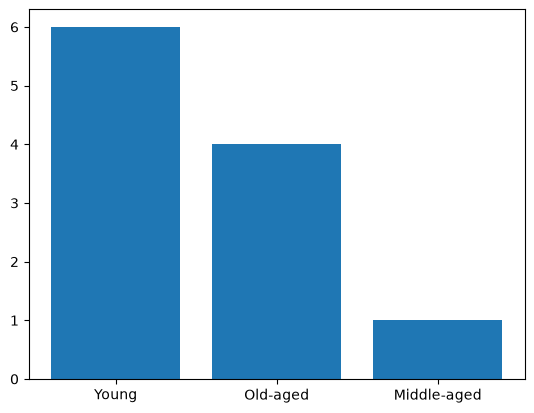

In [21]:
import matplotlib.pyplot as plt

plt.bar(x = count.index, height = count.values)

## Detecting and Filtering Outliers 

C:\Users\Zohaib Ali\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:128: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[self.orient] = ""
C:\Users\Zohaib Ali\AppData\Roaming\Python\Python314\site-packages\

<Axes: ylabel='Salary'>

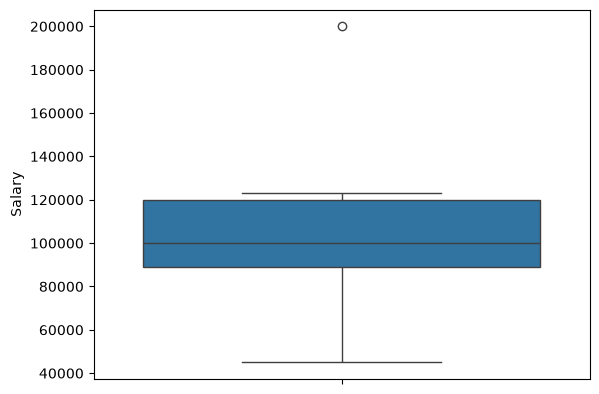

In [23]:
import seaborn as sns

sns.boxplot(data.Salary)

## Minimum sai phele and maximun kai bd hotei outliers 


Q1 then Q3 

interquartile range = Q1 ka percentile + Q3 ka percentile



In [30]:
def detecting_outliers(col):
    Q1 = np.percentile(col, 25)
    Q3 = np.percentile(col, 75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    return lower_limit, upper_limit





In [29]:
import numpy as np

np.percentile(data.Age, 75)

np.float64(45.0)

In [25]:
data.isna().sum()

Serial         0
Emp_ID         0
Designation    0
Department     2
Age            1
Salary         3
Age_group      1
dtype: int64

In [26]:
data.Age.fillna(data.Age.median(), inplace = True)

C:\Users\Zohaib Ali\AppData\Local\Temp\ipykernel_9636\2782078666.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Age.fillna(data.Age.median(), inplace = True)


In [27]:
data.isna().sum()

Serial         0
Emp_ID         0
Designation    0
Department     2
Age            0
Salary         3
Age_group      1
dtype: int64

In [31]:
data.Salary.fillna(data.Salary.mean(), inplace = True)

C:\Users\Zohaib Ali\AppData\Local\Temp\ipykernel_9636\4230030955.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Salary.fillna(data.Salary.mean(), inplace = True)


In [32]:
data.isna().sum()

Serial         0
Emp_ID         0
Designation    0
Department     2
Age            0
Salary         0
Age_group      1
dtype: int64

In [34]:
lb,up = detecting_outliers(data.Salary)

In [35]:
data[(data.Salary < lb) | (data.Salary > up)]

,Serial,Emp_ID,Designation,Department,Age,Salary,Age_group
0,1,1101,Manager,Accounts,50.0,200000.0,Old-aged
4,5,2123,Office Boy,Accounts,27.0,45000.0,Young
